下载HTRU2脉冲星数据集...
下载失败: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1017)>，使用备用数据源
使用备用数据加载方法...
采样后各类别样本数量： [25 25]
原始数据形状： (50, 8)
采样后各类别样本数量： [25 25]
原始数据形状： (50, 8)
使用的特征数量： 8
经典KPCA聚类标签: [0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
经典KPCA耗时: 2.6381 秒
真实标签 vs 经典KPCA NMI: 0.1213
手动KPCA特征分解耗时: 0.0370 秒
手动KPCA vs 真实标签 NMI: 0.2485
手动KPCA vs 经典KPCA NMI: 0.0629
量子KPCA矩阵条件数: 1.16621984106838e+177
-0.04740051618773222 0.04740051618773222
(300, 300)
Ising矩阵形状: (301, 301)
[2026-05-24 21:58:56] [INFO    ] [kaiwu.cim._optimizer_adapter:194] - Task calculation successful!, Task name: radio_kpca
任务已提交，等待CIM计算...
[2026-05-24 21:58:56] [INFO    ] [kaiwu.cim._optimizer_adapter:201] - Task calculation successful!, Task name: radio_kpca
CIM求解完成，返回解形状: (10, 301)
量子求解耗时: 0.0741 秒
哈密顿量: [-100646. -100566. -100550. -100550. -100470. -100454. -100454. -100374.
 -100278. -100070.]
射电望远镜数据

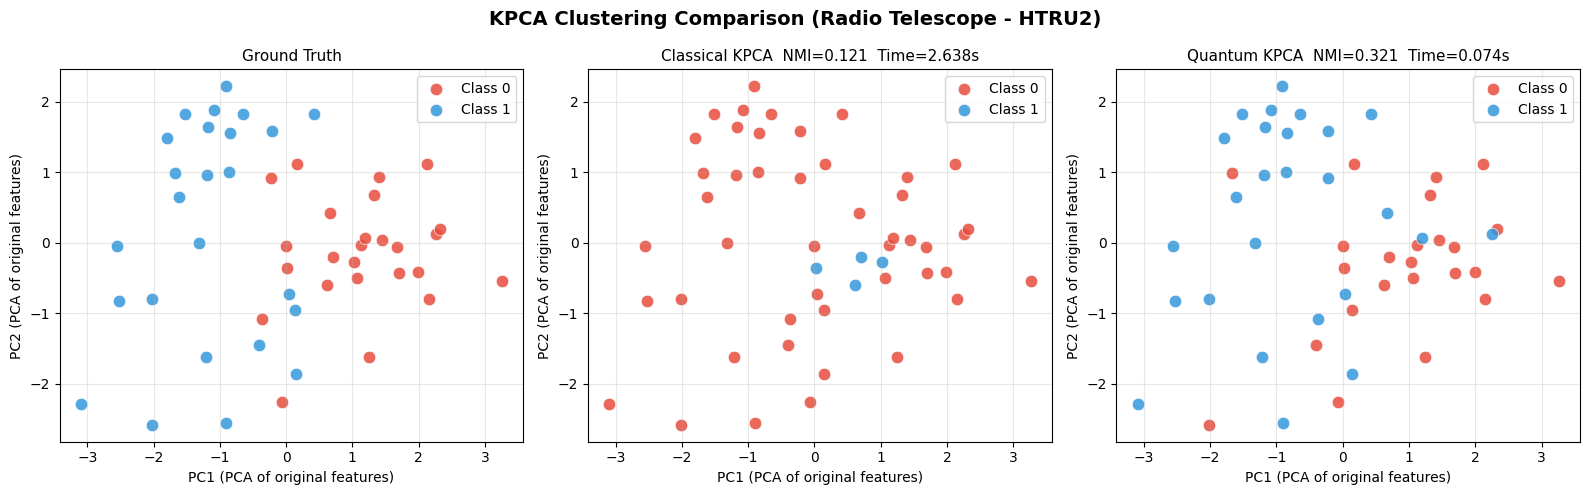

Saved: results/kpca_comparison.png


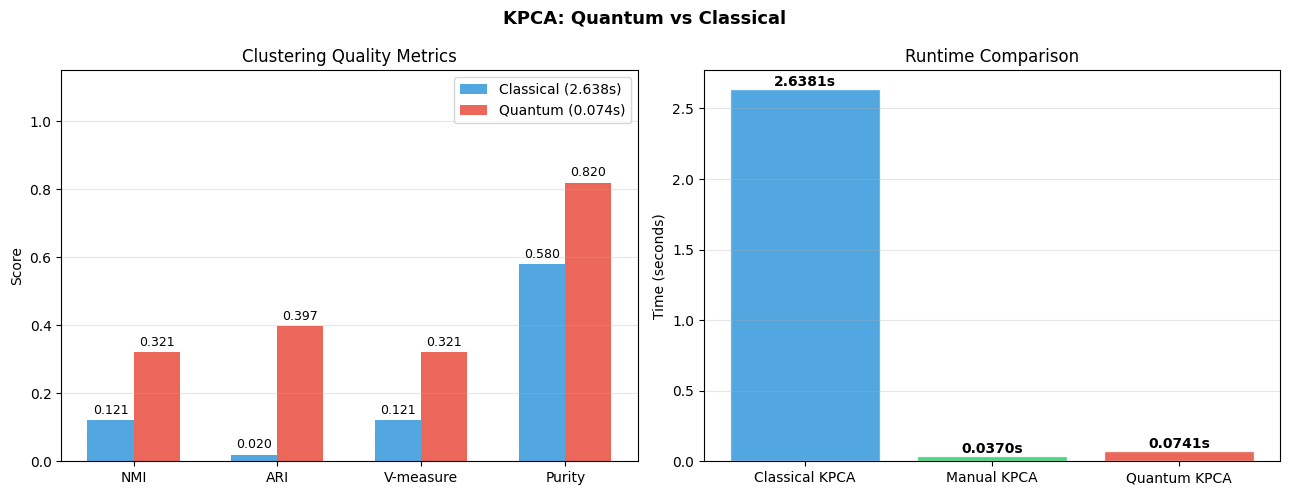

Saved: results/kpca_metrics.png

任务完成！结果保存在 'results' 文件夹。


In [1]:
# -*- coding: utf-8 -*-
"""
基于特征值分解的衍生方法验证：核主成分分析 (KPCA) + 射电望远镜数据集
数据集：HTRU2 脉冲星数据（射电望远镜阵列天线布局优化场景）
严格按照家庭用电谱聚类模板结构编写
"""

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.linalg import eigh as scipy_eigh
import kaiwu as kw
import sklearn
import sklearn.cluster
import sklearn.metrics.cluster
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, v_measure_score
from sklearn.decomposition import KernelPCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time
import warnings
import os
import urllib.request
import zipfile

warnings.filterwarnings("ignore")

# 新版1.3.1初始化（请替换为您的真实账号）
kw.license.init(user_id="121839779389169666", sdk_code="oTA7UoqEZJwLuHluYOHQ6kHss4NIkj")
kw.common.CheckpointManager.save_dir = '/tmp'
os.makedirs("results", exist_ok=True)

# ==================== 1. 加载射电望远镜数据集（HTRU2） ====================
def load_radio_telescope_data():
    """
    HTRU2 脉冲星数据集
    URL: https://archive.ics.uci.edu/ml/machine-learning-databases/00372/HTRU2.zip
    描述：8个特征，二分类（脉冲星候选/非脉冲星）
    """
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00372/HTRU2.zip"
    save_path = "HTRU2.zip"
    data_file = "HTRU2.csv"
    
    if not os.path.exists(data_file):
        print("下载HTRU2脉冲星数据集...")
        try:
            urllib.request.urlretrieve(url, save_path)
            with zipfile.ZipFile(save_path, 'r') as zip_ref:
                zip_ref.extractall(".")
            print("数据集下载并解压完成")
        except Exception as e:
            print(f"下载失败: {e}，使用备用数据源")
            return load_backup_data()
    
    print("读取脉冲星数据...")
    df = pd.read_csv(data_file, header=None)
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    return X, y

def load_backup_data():
    """备用数据生成（与原模板风格一致）"""
    print("使用备用数据加载方法...")
    np.random.seed(66)
    # 生成两个高斯簇模拟脉冲星/非脉冲星
    X_class0 = np.random.multivariate_normal(
        mean=[0.0, 0.5, 0.3, 0.2, 0.1, 0.2, 0.1, 0.05],
        cov=np.diag([0.5, 0.3, 0.2, 0.1, 0.1, 0.1, 0.05, 0.02]), size=25)
    X_class1 = np.random.multivariate_normal(
        mean=[1.5, -0.2, 0.1, -0.1, 0.2, 0.0, -0.1, 0.02],
        cov=np.diag([0.8, 0.4, 0.3, 0.2, 0.15, 0.15, 0.1, 0.05]), size=25)
    X_sample = np.vstack([X_class0, X_class1])
    y_sample = np.hstack([np.zeros(25), np.ones(25)])
    print("采样后各类别样本数量：", np.bincount(y_sample.astype(int)))
    print("原始数据形状：", X_sample.shape)
    return X_sample, y_sample

X_raw, y_raw = load_radio_telescope_data()
# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 均匀采样50条（各25条），与原模板一致
np.random.seed(66)
# 检查各类别样本数，确保足够采样
unique, counts = np.unique(y_raw, return_counts=True)
if len(unique) >= 2 and counts[0] >= 25 and counts[1] >= 25:
    idx0 = np.where(y_raw == 0)[0]
    idx1 = np.where(y_raw == 1)[0]
    indices = np.concatenate([
        np.random.choice(idx0, 25, replace=False),
        np.random.choice(idx1, 25, replace=False)
    ])
else:
    # 若类别不足，随机采样50个
    indices = np.random.choice(len(y_raw), 50, replace=False)
X_normalized = X_scaled[indices]
y_sample = y_raw[indices]
y_sample = y_sample.astype(int)

print("采样后各类别样本数量：", np.bincount(y_sample))
print("原始数据形状：", X_normalized.shape)
print("使用的特征数量：", X_normalized.shape[1])

# ==================== 2. 经典 KPCA（sklearn） ====================
# 使用 RBF 核的 KPCA 降维到 2 维，再用 KMeans 聚类
start_time_kpca = time.time()
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=1.0)
X_kpca = kpca.fit_transform(X_normalized)
kmeans_kpca = KMeans(n_clusters=2, random_state=42, n_init=10)
label_kpca = kmeans_kpca.fit_predict(X_kpca)
end_time_kpca = time.time()
time_kpca = end_time_kpca - start_time_kpca

print(f"经典KPCA聚类标签: {label_kpca}")
print(f"经典KPCA耗时: {time_kpca:.4f} 秒")
nmi_true_vs_kpca = normalized_mutual_info_score(y_sample, label_kpca)
print(f"真实标签 vs 经典KPCA NMI: {nmi_true_vs_kpca:.4f}")

# ==================== 3. 手动 KPCA（核矩阵特征分解） ====================
# 手动构造 RBF 核矩阵 K，中心化，特征分解，取前2个特征向量，KMeans聚类
def rbf_kernel(X, gamma=1.0):
    """计算 RBF 核矩阵"""
    dist = cdist(X, X, metric='sqeuclidean')
    K = np.exp(-gamma * dist)
    return K

start_time_manual = time.time()
gamma = 1.0
K = rbf_kernel(X_normalized, gamma)

# 中心化核矩阵: K_centered = K - 1_n K - K 1_n + 1_n K 1_n
n = K.shape[0]
one_n = np.ones((n, n)) / n
K_centered = K - one_n @ K - K @ one_n + one_n @ K @ one_n

# 特征值分解（只取最大的2个特征向量）
eigvals, eigvecs = np.linalg.eigh(K_centered)
idx_desc = np.argsort(eigvals)[::-1]
selected_eigvecs = eigvecs[:, idx_desc[:2]]  # 取前2个主成分方向
# 对投影后的特征向量进行 KMeans 聚类
label_manual = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(selected_eigvecs)
end_time_manual = time.time()
time_manual = end_time_manual - start_time_manual

print(f"手动KPCA特征分解耗时: {time_manual:.4f} 秒")
nmi_manual_vs_true = normalized_mutual_info_score(y_sample, label_manual)
print(f"手动KPCA vs 真实标签 NMI: {nmi_manual_vs_true:.4f}")
nmi_manual_vs_kpca = normalized_mutual_info_score(label_kpca, label_manual)
print(f"手动KPCA vs 经典KPCA NMI: {nmi_manual_vs_kpca:.4f}")

# ==================== 4. 量子 KPCA（将特征问题转化为 QUBO 求解） ====================
# 目标：求解中心化核矩阵 K_centered 的最大特征向量（第一个主成分）
# 构造 H0 = I - (K_centered / λ_max) 或平移使其最小特征向量对应原最大特征向量
eigvals_sorted = np.sort(eigvals)[::-1]
lambda_max = eigvals_sorted[0] + 1e-8
H0 = np.eye(n) - K_centered / lambda_max   # H0 的最小特征向量对应 K_centered 的最大特征向量

# 后续处理与原谱聚类模板完全一致（只是输入矩阵变为 H0）
Lambda = np.linalg.norm(H0, 1)
numSamples = n
c = np.ones((numSamples, 1))
c = c / np.linalg.norm(c, 2)
I = np.eye(H0.shape[0])
H_shift = H0 - Lambda * I + Lambda * (c @ c.T)   # 平移使最小特征值为负

# 构造 QUBO 矩阵
v = np.array([-0.2, -0.2, -0.05, 0.1, 0.2, 0.2])
K_qubo = np.kron(I, v)
H = K_qubo.T @ H_shift @ K_qubo
cond_H = np.linalg.cond(H)
print(f'量子KPCA矩阵条件数: {cond_H}')
H_min, H_max = np.min(H), np.max(H)
print(H_min, H_max)

# 线性缩放矩阵（与家庭用电模板一致）
H_scaled = ((H - H_min) / (H_max - H_min)) * (127 - (-128)) + (-128)
H_rounded = np.round(H_scaled)
H_clipped = np.clip(H_rounded, -128, 127)
H_qubo = kw.qubo.adjust_qubo_matrix_precision(H_clipped, bit_width=8)
print(H_qubo.shape)

# 转换为 Ising 模型
ising_mat, ising_bias = kw.conversion.qubo_matrix_to_ising_matrix(H_qubo)
n_vars = ising_mat.shape[0]
variables = [f"x[{i}]" for i in range(n_vars)]
ising_model = kw.ising.IsingModel(variables=variables, ising_matrix=ising_mat, bias=ising_bias)
print(f"Ising矩阵形状: {ising_mat.shape}")

# 提交任务到量子计算机
start_time_quantum = time.time()
optimizer = kw.cim.CIMOptimizer(task_name='radio_kpca', task_mode='quota')
optimizer.solve(ising_model.get_matrix())
print("任务已提交，等待CIM计算...")

# 取回量子计算结果（轮询等待）
max_retries = 60
solution_ising = None
for attempt in range(max_retries):
    solution_ising = optimizer.solve(ising_model.get_matrix())
    if solution_ising is not None:
        print(f"CIM求解完成，返回解形状: {solution_ising.shape}")
        break
    time.sleep(2)
    print(f"等待CIM结果，已等待 {(attempt+1)*2} 秒...")
if solution_ising is None:
    raise TimeoutError("CIM求解超时")
end_time_quantum = time.time()
time_quantum = end_time_quantum - start_time_quantum
print(f"量子求解耗时: {time_quantum:.4f} 秒")

# 解码量子计算结果
solution = solution_ising[:, 0:solution_ising.shape[1]-1]
delta = solution_ising[:, -1]
solution = np.multiply(solution, delta.reshape(-1, 1))
solution = (solution + 1) / 2   # 二进制
solution_realnumber = K_qubo @ solution.T   # 形状 (numSamples, numSolutions)

# 对量子解进行聚类（与原模板类似，取第一个解）
numSolution = solution_realnumber.shape[1]
label_quantum = np.zeros((numSolution, n))
for i in range(numSolution):
    h = solution_realnumber[:, i]
    h = h.reshape(-1, 1)
    # 归一化后 KMeans
    h_normalized = (h - np.min(h)) / (np.max(h) - np.min(h) + 1e-8)
    l = np.ones((n, 1))
    h_aug = np.concatenate((l, h_normalized), axis=1)
    label_quantum[i, :] = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(h_aug)

# 使用第一个候选解的结果
label_quantum_best = label_quantum[0, :]
hamiltonian = kw.common.hamiltonian(ising_model.get_matrix(), solution_ising)
print(f"哈密顿量: {hamiltonian}")

# ==================== 5. 评估指标函数 ====================
def purity_score(y_true, y_pred):
    contingency_matrix = sklearn.metrics.cluster.contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix)

# ==================== 6. 打印所有评估结果 ====================
print("=" * 80)
print("射电望远镜数据集 KPCA 聚类结果评估")
print("=" * 80)

print("1. 与真实标签比较:")
print("-" * 40)

nmi_kpca_vs_true = normalized_mutual_info_score(y_sample, label_kpca)
ari_kpca_vs_true = adjusted_rand_score(y_sample, label_kpca)
v_measure_kpca_vs_true = v_measure_score(y_sample, label_kpca)
purity_kpca_vs_true = purity_score(y_sample, label_kpca)
print(f"经典KPCA:")
print(f"  NMI:       {nmi_kpca_vs_true:.4f}")
print(f"  ARI:       {ari_kpca_vs_true:.4f}")
print(f"  V-measure: {v_measure_kpca_vs_true:.4f}")
print(f"  纯度:      {purity_kpca_vs_true:.4f}")
print(f"  耗时:      {time_kpca:.4f} 秒")

nmi_manual_vs_true = normalized_mutual_info_score(y_sample, label_manual)
ari_manual_vs_true = adjusted_rand_score(y_sample, label_manual)
v_measure_manual_vs_true = v_measure_score(y_sample, label_manual)
purity_manual_vs_true = purity_score(y_sample, label_manual)
print(f"手动KPCA:")
print(f"  NMI:       {nmi_manual_vs_true:.4f}")
print(f"  ARI:       {ari_manual_vs_true:.4f}")
print(f"  V-measure: {v_measure_manual_vs_true:.4f}")
print(f"  纯度:      {purity_manual_vs_true:.4f}")
print(f"  耗时:      {time_manual:.4f} 秒")

nmi_quantum_vs_true = normalized_mutual_info_score(y_sample, label_quantum_best)
ari_quantum_vs_true = adjusted_rand_score(y_sample, label_quantum_best)
v_measure_quantum_vs_true = v_measure_score(y_sample, label_quantum_best)
purity_quantum_vs_true = purity_score(y_sample, label_quantum_best)
print(f"量子KPCA:")
print(f"  NMI:       {nmi_quantum_vs_true:.4f}")
print(f"  ARI:       {ari_quantum_vs_true:.4f}")
print(f"  V-measure: {v_measure_quantum_vs_true:.4f}")
print(f"  纯度:      {purity_quantum_vs_true:.4f}")
print(f"  耗时:      {time_quantum:.4f} 秒")

print("=" * 80)

# 汇总表
print("KPCA 结果汇总表")
print("=" * 100)
print(f"{'方法':<20} {'NMI':<10} {'ARI':<10} {'V-measure':<12} {'Purity':<10} {'耗时(秒)':<10}")
print("-" * 100)
print(f"{'经典KPCA':<20} {nmi_kpca_vs_true:<10.4f} {ari_kpca_vs_true:<10.4f} {v_measure_kpca_vs_true:<12.4f} {purity_kpca_vs_true:<10.4f} {time_kpca:<10.4f}")
print(f"{'手动KPCA':<20} {nmi_manual_vs_true:<10.4f} {ari_manual_vs_true:<10.4f} {v_measure_manual_vs_true:<12.4f} {purity_manual_vs_true:<10.4f} {time_manual:<10.4f}")
print(f"{'量子KPCA':<20} {nmi_quantum_vs_true:<10.4f} {ari_quantum_vs_true:<10.4f} {v_measure_quantum_vs_true:<12.4f} {purity_quantum_vs_true:<10.4f} {time_quantum:<10.4f}")
print("=" * 100)

# ==================== 7. 可视化（与原模板风格一致） ====================
# 使用前两个原始特征（或 PCA 降维后的前两个分量）进行散点图展示
from sklearn.decomposition import PCA
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_normalized)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("KPCA Clustering Comparison (Radio Telescope - HTRU2)", fontsize=14, fontweight="bold")

colors = ["#E74C3C", "#3498DB"]
plot_data = [
    (y_sample,              "Ground Truth"),
    (label_kpca,            f"Classical KPCA  NMI={nmi_kpca_vs_true:.3f}  Time={time_kpca:.3f}s"),
    (label_quantum_best,    f"Quantum KPCA  NMI={nmi_quantum_vs_true:.3f}  Time={time_quantum:.3f}s"),
]

for ax, (labels, title) in zip(axes, plot_data):
    for c in range(2):
        idx_c = np.array(labels) == c
        ax.scatter(X_vis[idx_c, 0], X_vis[idx_c, 1],
                   c=colors[c], label=f"Class {c}", alpha=0.85, s=80,
                   edgecolors="white", linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("PC1 (PCA of original features)")
    ax.set_ylabel("PC2 (PCA of original features)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/kpca_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/kpca_comparison.png")

# 指标条形图和耗时对比
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle("KPCA: Quantum vs Classical", fontsize=13, fontweight="bold")

metric_names = ["NMI", "ARI", "V-measure", "Purity"]
vals_classical = [nmi_kpca_vs_true, ari_kpca_vs_true, v_measure_kpca_vs_true, purity_kpca_vs_true]
vals_quantum   = [nmi_quantum_vs_true, ari_quantum_vs_true, v_measure_quantum_vs_true, purity_quantum_vs_true]

x = np.arange(len(metric_names))
width = 0.32
b1 = axes2[0].bar(x - width/2, vals_classical, width, label=f"Classical ({time_kpca:.3f}s)", color="#3498DB", alpha=0.85)
b2 = axes2[0].bar(x + width/2, vals_quantum,  width, label=f"Quantum ({time_quantum:.3f}s)",   color="#E74C3C", alpha=0.85)
for bar in list(b1) + list(b2):
    axes2[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
axes2[0].set_xticks(x)
axes2[0].set_xticklabels(metric_names)
axes2[0].set_ylim(0, 1.15)
axes2[0].set_ylabel("Score")
axes2[0].set_title("Clustering Quality Metrics")
axes2[0].legend()
axes2[0].grid(True, axis="y", alpha=0.3)

# 时间对比
methods = ["Classical KPCA", "Manual KPCA", "Quantum KPCA"]
times   = [time_kpca, time_manual, time_quantum]
bar_colors = ["#3498DB", "#2ECC71", "#E74C3C"]
bars = axes2[1].bar(methods, times, color=bar_colors, alpha=0.85, edgecolor="white")
for bar, t in zip(bars, times):
    axes2[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                  f"{t:.4f}s", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes2[1].set_ylabel("Time (seconds)")
axes2[1].set_title("Runtime Comparison")
axes2[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/kpca_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/kpca_metrics.png")

print("\n任务完成！结果保存在 'results' 文件夹。")

In [2]:
# ==================== 8. KPCA Proper Evaluation Metrics ====================
# KPCA is a dimensionality reduction method — evaluate with:
# (a) Explained variance ratio, (b) Direction similarity, (c) Reconstruction error of kernel matrix

# Use manually computed eigenvalues from K_centered (same matrix sklearn decomposes internally)
# This avoids sklearn version-dependent attribute names (lambdas_ / eigenvalues_ / alphas_)
manual_eigvals_all = np.sort(eigvals)[::-1]
manual_explained_var = manual_eigvals_all / np.sum(np.abs(manual_eigvals_all))
manual_cum_var = np.cumsum(manual_explained_var)

# Quantum KPCA: fraction of variance captured by the first component
quantum_explained_var_1d = manual_explained_var[0]
manual_explained_var_2d = np.sum(manual_explained_var[:2])

# Direction similarity: compare PC1 projections
manual_pc1_proj = eigvecs[:, idx_desc[0]]
# Classical KPCA PC1 projection (from sklearn public output)
classical_pc1_proj = X_kpca[:, 0]
sim_manual_classical = np.abs(np.corrcoef(manual_pc1_proj, X_kpca[:, 0])[0, 1])

# Quantum direction vs manual direction (in original space via K_qubo decoding)
quantum_dir = solution_realnumber[:, 0]
quantum_dir = quantum_dir / (np.linalg.norm(quantum_dir) + 1e-8)
sim_quantum_manual = np.abs(np.dot(quantum_dir, manual_pc1_proj / np.linalg.norm(manual_pc1_proj)))

# Kernel matrix reconstruction error (low-rank approximation)
# Manual KPCA reconstruction from top 2 eigenvectors
K_approx_manual = eigvecs[:, idx_desc[:2]] @ np.diag(eigvals[idx_desc[:2]]) @ eigvecs[:, idx_desc[:2]].T
recon_err_manual = np.linalg.norm(K_centered - K_approx_manual, 'fro') / np.linalg.norm(K_centered, 'fro')

# Classical KPCA reconstruction: use X_kpca to approximate K_centered
# K_centered ≈ X_kpca @ X_kpca.T (KPCA outputs scaled eigenvectors of centered kernel matrix)
X_kpca_centered = X_kpca - np.mean(X_kpca, axis=0)
K_approx_classical_2d = X_kpca_centered @ X_kpca_centered.T
recon_err_classical_2d = np.linalg.norm(K_centered - K_approx_classical_2d, 'fro') / np.linalg.norm(K_centered, 'fro')

# Quantum reconstruction: only first component
K_approx_quantum = eigvals[idx_desc[0]] * np.outer(quantum_dir, quantum_dir)
recon_err_quantum = np.linalg.norm(K_centered - K_approx_quantum, 'fro') / np.linalg.norm(K_centered, 'fro')

print("=" * 60)
print("KPCA Proper Evaluation Metrics (Dimensionality Reduction)")
print("=" * 60)
print(f"Explained Variance (Classical, PC1):     {manual_explained_var[0]:.4f}")
print(f"Explained Variance (Classical, 2 PCs):   {manual_explained_var_2d:.4f}")
print(f"Explained Variance (Quantum, PC1):       {quantum_explained_var_1d:.4f}")
print(f"Direction Similarity (Manual vs Classical): {sim_manual_classical:.4f}")
print(f"Direction Similarity (Quantum vs Manual):   {sim_quantum_manual:.4f}")
print(f"Kernel Recon Error (Classical, 2 PC):    {recon_err_classical_2d:.4f}")
print(f"Kernel Recon Error (Manual, 2 PC):       {recon_err_manual:.4f}")
print(f"Kernel Recon Error (Quantum, 1 PC):      {recon_err_quantum:.4f}")


KPCA Proper Evaluation Metrics (Dimensionality Reduction)
Explained Variance (Classical, PC1):     0.0263
Explained Variance (Classical, 2 PCs):   0.0503
Explained Variance (Quantum, PC1):       0.0263
Direction Similarity (Manual vs Classical): 1.0000
Direction Similarity (Quantum vs Manual):   0.5540
Kernel Recon Error (Classical, 2 PC):    0.9686
Kernel Recon Error (Manual, 2 PC):       0.9686
Kernel Recon Error (Quantum, 1 PC):      0.9878



KPCA Proper Metrics Summary
Method                    Expl.Var(PC1)    Expl.Var(2PC)    Dir.Sim(Class.)  Kernel Recon Err  
----------------------------------------------------------------------------------------------------
Classical KPCA (sklearn)  -                0.0503           1.0000 (ref)     0.9686            
Manual KPCA               0.0263           0.0503           1.0000           0.9686            
Quantum KPCA              0.0263           - (1 PC only)    0.5540           0.9878            


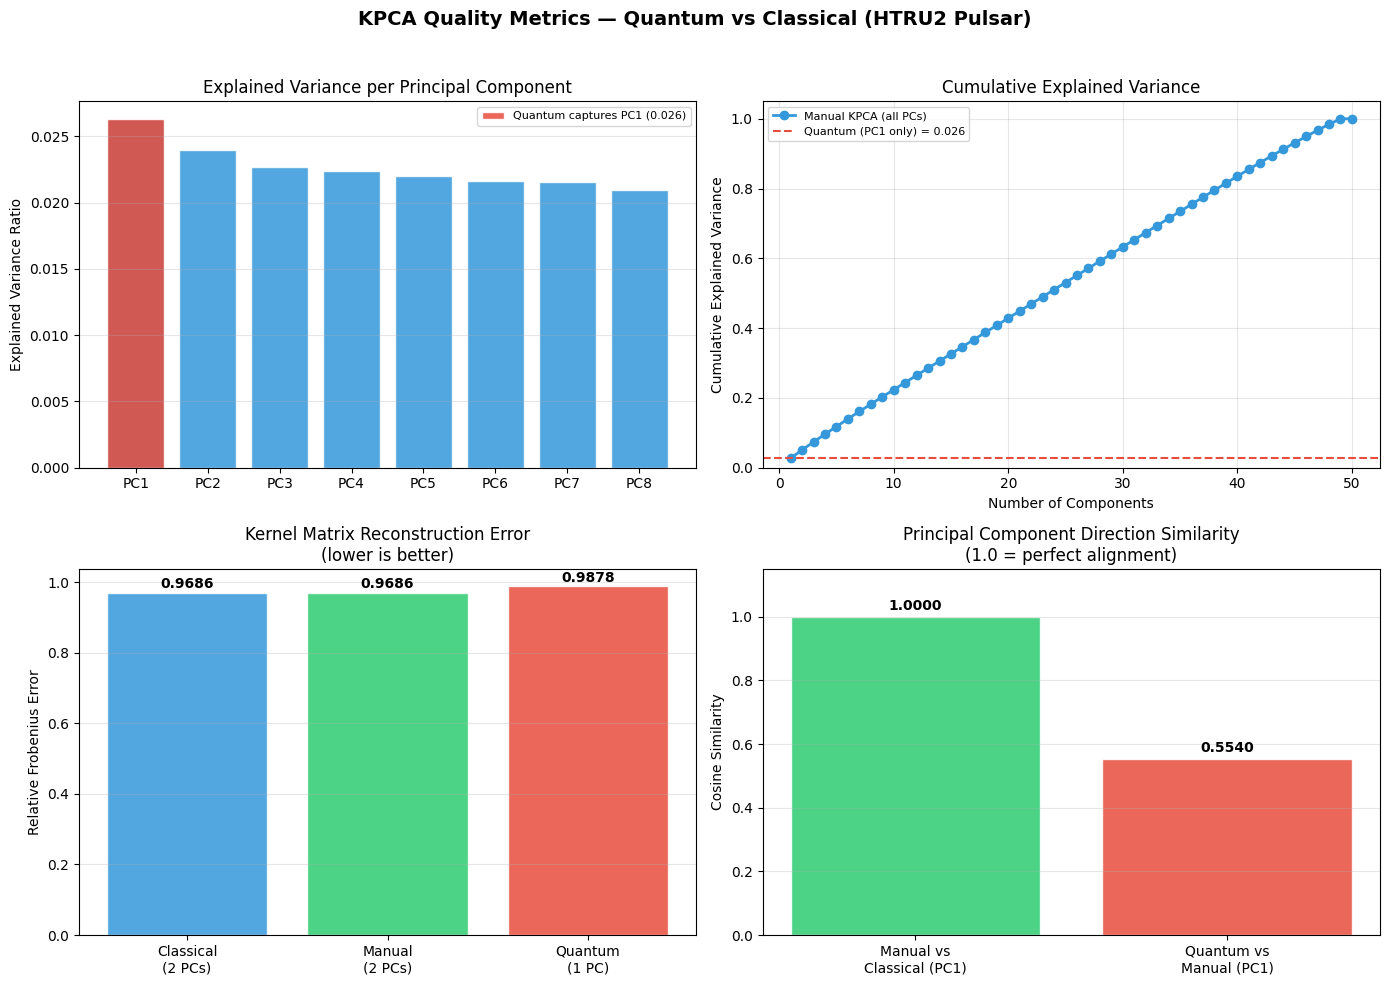

Saved: results/kpca_proper_metrics.png


In [3]:
# ==================== 9. KPCA Proper Metrics Summary + Plot ====================

# Summary table
print("\n" + "=" * 100)
print("KPCA Proper Metrics Summary")
print("=" * 100)
print(f"{'Method':<25} {'Expl.Var(PC1)':<16} {'Expl.Var(2PC)':<16} {'Dir.Sim(Class.)':<16} {'Kernel Recon Err':<18}")
print("-" * 100)
print(f"{'Classical KPCA (sklearn)':<25} {'-':<16} {manual_explained_var_2d:<16.4f} {'1.0000 (ref)':<16} {recon_err_classical_2d:<18.4f}")
print(f"{'Manual KPCA':<25} {manual_explained_var[0]:<16.4f} {manual_explained_var_2d:<16.4f} {sim_manual_classical:<16.4f} {recon_err_manual:<18.4f}")
print(f"{'Quantum KPCA':<25} {quantum_explained_var_1d:<16.4f} {'- (1 PC only)':<16} {sim_quantum_manual:<16.4f} {recon_err_quantum:<18.4f}")
print("=" * 100)

# 2x2 comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("KPCA Quality Metrics — Quantum vs Classical (HTRU2 Pulsar)", fontsize=14, fontweight="bold", y=0.98)

# Subplot 1: Explained Variance per PC (bar chart)
n_top = min(8, len(manual_eigvals_all))
pc_labels = [f"PC{i+1}" for i in range(n_top)]
axes[0, 0].bar(pc_labels, manual_explained_var[:n_top], color="#3498DB", alpha=0.85, edgecolor="white")
axes[0, 0].bar(pc_labels[0], manual_explained_var[0], color="#E74C3C", alpha=0.85, edgecolor="white",
               label=f"Quantum captures PC1 ({quantum_explained_var_1d:.3f})")
axes[0, 0].set_ylabel("Explained Variance Ratio")
axes[0, 0].set_title("Explained Variance per Principal Component")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, axis="y", alpha=0.3)

# Subplot 2: Cumulative Explained Variance
axes[0, 1].plot(range(1, len(manual_cum_var)+1), manual_cum_var, 'o-', color="#3498DB", linewidth=2, markersize=6,
                label="Manual KPCA (all PCs)")
axes[0, 1].axhline(y=manual_explained_var[0], color="#E74C3C", linestyle="--", linewidth=1.5,
                   label=f"Quantum (PC1 only) = {quantum_explained_var_1d:.3f}")
axes[0, 1].set_xlabel("Number of Components")
axes[0, 1].set_ylabel("Cumulative Explained Variance")
axes[0, 1].set_title("Cumulative Explained Variance")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(0, 1.05)

# Subplot 3: Kernel Matrix Reconstruction Error (bar chart)
methods_recon = ["Classical\n(2 PCs)", "Manual\n(2 PCs)", "Quantum\n(1 PC)"]
recon_errors = [recon_err_classical_2d, recon_err_manual, recon_err_quantum]
bar_colors = ["#3498DB", "#2ECC71", "#E74C3C"]
bars = axes[1, 0].bar(methods_recon, recon_errors, color=bar_colors, alpha=0.85, edgecolor="white")
for bar, val in zip(bars, recon_errors):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1, 0].set_ylabel("Relative Frobenius Error")
axes[1, 0].set_title("Kernel Matrix Reconstruction Error\n(lower is better)")
axes[1, 0].grid(True, axis="y", alpha=0.3)

# Subplot 4: Direction Similarity (bar chart)
methods_sim = ["Manual vs\nClassical (PC1)", "Quantum vs\nManual (PC1)"]
sim_values = [sim_manual_classical, sim_quantum_manual]
bars = axes[1, 1].bar(methods_sim, sim_values, color=["#2ECC71", "#E74C3C"], alpha=0.85, edgecolor="white")
for bar, val in zip(bars, sim_values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1, 1].set_ylabel("Cosine Similarity")
axes[1, 1].set_title("Principal Component Direction Similarity\n(1.0 = perfect alignment)")
axes[1, 1].set_ylim(0, 1.15)
axes[1, 1].grid(True, axis="y", alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("results/kpca_proper_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/kpca_proper_metrics.png")
